
# AI Portfolio for Finance and Banking — Fraud, Anomaly Detection, and Time-Series Risk Modeling

**Author:** David Sanz  
**Project positioning:** AI / ML Engineering for banking, fraud, risk, and advanced analytics

## Project purpose
This notebook has a dual objective:
1. Present a technically solid academic deliverable with multiple machine learning exercises aligned with a university assignment.
2. Build a portfolio artifact that demonstrates how I approach applied AI problems in financial services, especially in fraud detection, anomaly detection, and sequential risk signals.

## What this notebook demonstrates
This notebook is intentionally written as a professional technical document rather than a code dump. Each section explains:
- the business problem,
- why a given modeling approach is appropriate,
- how the data is prepared,
- how the model is trained and evaluated,
- and how the results should be interpreted in a financial context.

## Cases included
### Case 1 — Supervised fraud detection with an MLP
A dense neural network for rare-event classification on synthetic transactional data.

### Case 2 — Anomaly detection with an Autoencoder
An unsupervised reconstruction model trained on normal behavior to detect unusual operations.

### Case 3 — Time-series regime prediction with a GRU
A recurrent neural network that anticipates periods of high volatility using sequential market-style features.



# 1. Notebook Reading Guide

## Structure used throughout the notebook
Each section follows the same logic:
1. **Business problem** — what needs to be solved.
2. **Model choice** — why this approach is suitable.
3. **Data design and feature logic** — what variables represent and why they matter.
4. **Training setup** — how the model learns.
5. **Evaluation** — how performance is measured.
6. **Business interpretation** — what the result means in a banking or financial setting.

This structure mirrors how applied AI work is typically communicated in industry: model performance matters, but so do traceability, reasoning, and business relevance.



# 2. Imports, Environment Setup, and Reproducibility

## Why this section matters
In real AI projects, reproducibility is not optional. If results change every time the notebook runs, it becomes harder to validate models, compare experiments, or defend conclusions.

This section does three things:
- imports the main libraries for data analysis, visualization, and deep learning,
- fixes random seeds across libraries,
- and sets a simple plotting configuration.


In [10]:

import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True

print('TensorFlow version:', tf.__version__)
print('Seed used:', SEED)


TensorFlow version: 2.21.0
Seed used: 42



# 3. Synthetic Data with Financial Logic

## Why use synthetic data?
For an academic and portfolio-oriented notebook, synthetic data has several advantages:
- the notebook is self-contained,
- it does not depend on external files or private credentials,
- it allows a full end-to-end pipeline to be demonstrated,
- and the modeling logic remains transferable to real banking datasets.

## Case 1 dataset design — fraud as an imbalanced classification problem
Fraud detection typically has the following properties:
- many numerical features derived from customer and transaction behavior,
- a very small positive class,
- noisy signals,
- and some redundancy across variables.

To reflect that, I generate a synthetic dataset with:
- **25,000 records**,
- **32 numerical features**,
- a small minority fraud class,
- informative, redundant, and noisy features.

## Why these variables make sense
The features are synthetic, but they can be interpreted as realistic transaction-level signals such as:
- customer behavior aggregates,
- transaction scoring variables,
- velocity-based flags,
- account usage patterns,
- device or channel behavior,
- and engineered fraud indicators.

The goal is not to simulate one exact banking system, but to build a realistic tabular setup for rare-event modeling.


In [11]:

# Synthetic fraud dataset
X, y = make_classification(
    n_samples=25000,
    n_features=32,
    n_informative=18,
    n_redundant=8,
    n_repeated=0,
    n_classes=2,
    weights=[0.992, 0.008],
    class_sep=1.5,
    flip_y=0.01,
    random_state=SEED
)

feature_names = [f'feature_{i:02d}' for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df['fraud'] = y

print('Dataset shape:', df.shape)
print('Fraud rate:', f"{df['fraud'].mean():.2%}")
df.head()


Dataset shape: (25000, 33)
Fraud rate: 1.31%


,feature_00,feature_01,feature_02,feature_03,feature_04,feature_05,feature_06,feature_07,feature_08,feature_09,...,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,fraud
0,-0.587269,-0.085535,-1.621854,-6.561061,-5.969351,-0.519649,-1.027638,-5.388123,1.587923,-0.310036,...,0.183089,-0.909734,5.091006,3.147551,2.295330,-9.313174,2.333398,-4.413239,3.197095,0
1,-2.531270,0.298311,-3.998653,-3.798839,-7.308620,-3.397277,0.892797,-1.365592,2.804921,-0.319612,...,0.382548,-0.323909,3.255154,1.997997,0.551331,-3.540779,5.077496,-2.606907,2.052410,0
2,1.610924,1.480416,-3.417295,-0.197364,-8.802697,-0.696828,-1.607940,0.962989,-2.082820,1.809025,...,-1.462489,-2.314510,-1.462788,6.157491,12.432172,-10.917495,3.488716,-1.823217,3.284482,0
3,-0.456429,0.878066,2.235787,-6.890808,3.768810,-1.296489,-1.036424,-0.087876,2.664450,0.205994,...,-0.814436,-1.710628,0.696329,4.137901,-0.085833,-2.498576,5.571474,-1.808895,3.202775,0
4,-1.475002,0.840345,2.684206,3.246347,2.027238,-2.224923,4.665901,-5.326715,0.982017,-0.927908,...,-1.554825,-2.296272,-0.926658,-2.591724,0.949340,-9.284832,-3.113953,-0.695257,0.589041,0


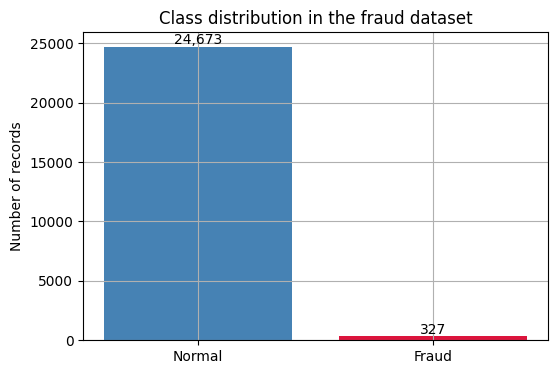

In [12]:

class_counts = df['fraud'].value_counts().sort_index()
labels = ['Normal', 'Fraud']

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, class_counts.values, color=['steelblue', 'crimson'])
ax.set_title('Class distribution in the fraud dataset')
ax.set_ylabel('Number of records')
for i, v in enumerate(class_counts.values):
    ax.text(i, v + max(class_counts.values) * 0.01, f'{v:,}', ha='center')
plt.show()



# 4. Train / Validation / Test Split and Feature Scaling

## What is done here
- The dataset is split into **train**, **validation**, and **test** sets.
- Numerical features are standardized using `StandardScaler`.

## Why this matters
### 1) A correct split strategy
The test set should only be used at the end. If it is used to tune thresholds or model choices, evaluation becomes optimistic and less trustworthy.

### 2) Standardization for neural networks
Dense neural networks generally train more reliably when input variables are on comparable scales.

## Why a three-way split is useful in this notebook
The validation set is used for:
- threshold selection,
- early stopping,
- and model monitoring.

This mirrors a professional workflow more closely than training on a single split and reporting metrics directly.


In [13]:

X = df.drop(columns='fraud').values
y = df['fraud'].values

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1765, stratify=y_train_full, random_state=SEED
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

print('Train      :', X_train_sc.shape, '| fraud rate:', f'{y_train.mean():.2%}')
print('Validation :', X_val_sc.shape, '| fraud rate:', f'{y_val.mean():.2%}')
print('Test       :', X_test_sc.shape, '| fraud rate:', f'{y_test.mean():.2%}')


Train      : (17499, 32) | fraud rate: 1.31%
Validation : (3751, 32) | fraud rate: 1.31%
Test       : (3750, 32) | fraud rate: 1.31%



# 5. Case 1 — Supervised Fraud Detection with an MLP

## Business problem
The objective is to identify suspicious transactions that should be prioritized for review or blocked before settlement. In fraud detection, the key challenge is that the positive class is rare but economically very important.

## Why choose an MLP?
A **Multi-Layer Perceptron (MLP)** is a reasonable deep learning baseline for tabular numerical data when:
- feature interactions may be non-linear,
- the problem is binary classification,
- and a simple, explainable deep model is preferable to a more opaque or heavily tuned architecture.

## Why not start with a more complex model?
Models such as XGBoost, LightGBM, or entity-aware architectures are often strong in real fraud systems. However, for this notebook the MLP is a good fit because it:
- clearly demonstrates deep learning on tabular data,
- remains easy to document,
- and provides a solid benchmark for future comparison.

## Why use class weights?
Because fraud is rare, an unadjusted model may learn to classify almost everything as normal. Class weighting increases the penalty for missing fraud cases and makes the optimization more aligned with the business objective.

## Why this architecture?
- **Dense layers** learn non-linear combinations of engineered transaction signals.
- **Dropout** reduces overfitting risk.
- **Sigmoid output** produces a fraud probability between 0 and 1.
- The network depth is deliberately moderate to keep the model expressive yet defensible.


In [14]:

input_dim = X_train_sc.shape[1]

mlp = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.15),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc')]
)

neg, pos = np.bincount(y_train)
class_weight = {0: 1.0, 1: float(neg / pos) * 0.7}
print('Class weights:', class_weight)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc', mode='max', patience=6, restore_best_weights=True
    )
]

history_mlp = mlp.fit(
    X_train_sc, y_train,
    validation_data=(X_val_sc, y_val),
    epochs=30,
    batch_size=256,
    verbose=0,
    class_weight=class_weight,
    callbacks=callbacks
)

print('Best validation AUC:', max(history_mlp.history['val_auc']))


Class weights: {0: 1.0, 1: 52.790393013100434}
Best validation AUC: 0.7006113529205322



## Why monitor AUC during training?
Accuracy is often misleading in imbalanced classification. AUC is more stable during optimization and provides a broader view of ranking quality than raw accuracy.


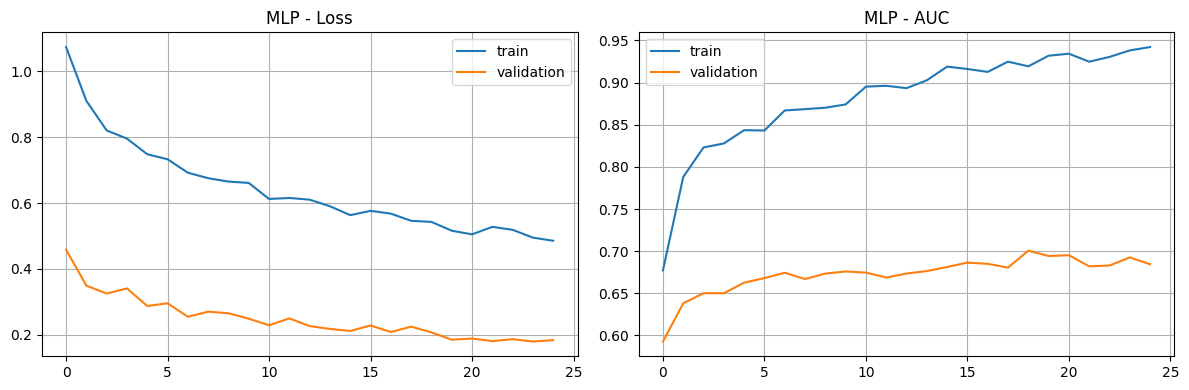

In [15]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_mlp.history['loss'], label='train')
axes[0].plot(history_mlp.history['val_loss'], label='validation')
axes[0].set_title('MLP - Loss')
axes[0].legend()

axes[1].plot(history_mlp.history['auc'], label='train')
axes[1].plot(history_mlp.history['val_auc'], label='validation')
axes[1].set_title('MLP - AUC')
axes[1].legend()

plt.tight_layout()
plt.show()



# 6. Threshold Selection on the Validation Set

## Why not use 0.5 by default?
A score threshold of 0.5 is arbitrary unless it matches the business objective.

In fraud operations, threshold choice depends on the cost structure:
- if missing fraud is expensive, recall may be prioritized,
- if false alerts overwhelm investigators, precision may be prioritized.

Here, I select the threshold that maximizes **F1 score** on validation data in order to obtain a balanced starting point between precision and recall.


Best threshold by F1: 0.80
Best validation F1: 0.5217


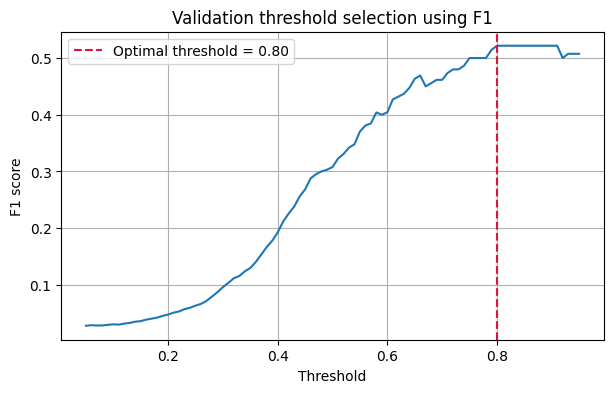

In [16]:

val_scores = mlp.predict(X_val_sc, verbose=0).ravel()
thresholds = np.linspace(0.05, 0.95, 91)

f1s = []
for thr in thresholds:
    preds = (val_scores >= thr).astype(int)
    f1s.append(f1_score(y_val, preds, zero_division=0))

best_idx = int(np.argmax(f1s))
best_thr = float(thresholds[best_idx])
best_f1 = float(f1s[best_idx])

print(f'Best threshold by F1: {best_thr:.2f}')
print(f'Best validation F1: {best_f1:.4f}')

plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1s)
plt.axvline(best_thr, color='crimson', linestyle='--', label=f'Optimal threshold = {best_thr:.2f}')
plt.title('Validation threshold selection using F1')
plt.xlabel('Threshold')
plt.ylabel('F1 score')
plt.legend()
plt.show()



# 7. Final Evaluation of the MLP on the Test Set

## Metrics used
- **ROC-AUC**: overall ranking separability.
- **PR-AUC**: especially informative when the positive class is rare.
- **Precision**: among flagged transactions, how many are true frauds.
- **Recall**: how many fraud cases are successfully detected.
- **F1**: a balanced summary of precision and recall.

## Why PR-AUC matters in fraud
In highly imbalanced problems, PR-AUC usually reflects practical performance better than accuracy and often better than ROC-AUC alone.


In [17]:

mlp_test_scores = mlp.predict(X_test_sc, verbose=0).ravel()
mlp_test_pred = (mlp_test_scores >= best_thr).astype(int)

mlp_roc_auc = roc_auc_score(y_test, mlp_test_scores)
mlp_pr_auc = average_precision_score(y_test, mlp_test_scores)
mlp_precision = precision_score(y_test, mlp_test_pred, zero_division=0)
mlp_recall = recall_score(y_test, mlp_test_pred, zero_division=0)
mlp_f1 = f1_score(y_test, mlp_test_pred, zero_division=0)

print('=== MLP TEST RESULTS ===')
print(f'ROC-AUC  : {mlp_roc_auc:.4f}')
print(f'PR-AUC   : {mlp_pr_auc:.4f}')
print(f'Precision: {mlp_precision:.4f}')
print(f'Recall   : {mlp_recall:.4f}')
print(f'F1-score : {mlp_f1:.4f}')
print('Classification report:')
print(classification_report(y_test, mlp_test_pred, digits=4))


=== MLP TEST RESULTS ===
ROC-AUC  : 0.7572
PR-AUC   : 0.5941
Precision: 0.9000
Recall   : 0.5510
F1-score : 0.6835
Classification report:
              precision    recall  f1-score   support

           0     0.9941    0.9992    0.9966      3701
           1     0.9000    0.5510    0.6835        49

    accuracy                         0.9933      3750
   macro avg     0.9470    0.7751    0.8401      3750
weighted avg     0.9929    0.9933    0.9925      3750



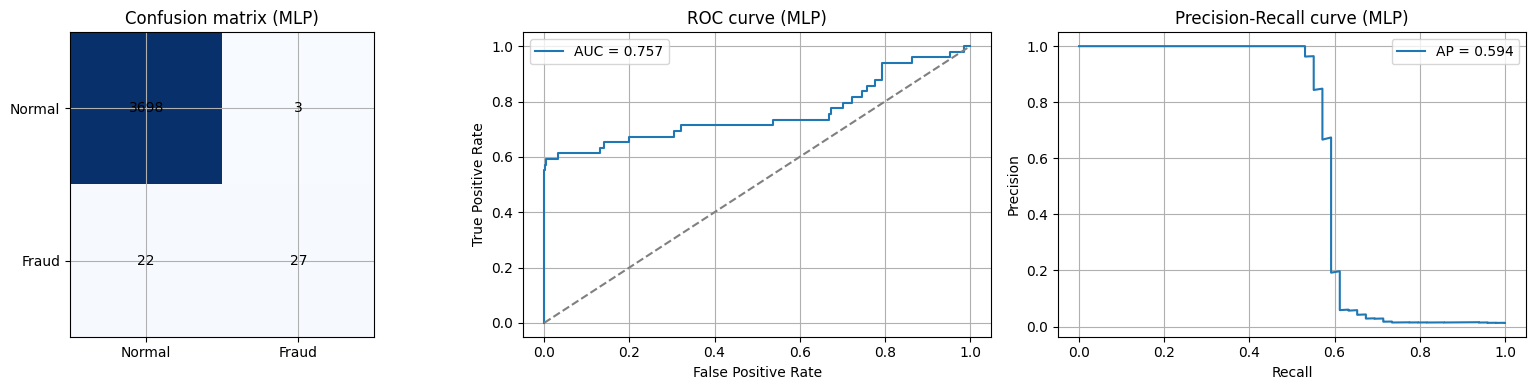

In [18]:

cm = confusion_matrix(y_test, mlp_test_pred)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].imshow(cm, cmap='Blues')
axes[0].set_title('Confusion matrix (MLP)')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Normal', 'Fraud'])
axes[0].set_yticklabels(['Normal', 'Fraud'])
for (i, j), v in np.ndenumerate(cm):
    axes[0].text(j, i, str(v), ha='center', va='center')

fpr, tpr, _ = roc_curve(y_test, mlp_test_scores)
axes[1].plot(fpr, tpr, label=f'AUC = {mlp_roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_title('ROC curve (MLP)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

precision_curve, recall_curve, _ = precision_recall_curve(y_test, mlp_test_scores)
axes[2].plot(recall_curve, precision_curve, label=f'AP = {mlp_pr_auc:.3f}')
axes[2].set_title('Precision-Recall curve (MLP)')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

plt.tight_layout()
plt.show()



# 8. Lightweight Interpretability

Neural networks for tabular data are not the most transparent models. To add a practical interpretability layer, I use **permutation importance** on a balanced logistic regression.

## Why this is still useful
This does **not** claim to exactly explain the MLP. Instead, it provides:
- a model-based approximation of which features carry predictive signal,
- a feature ranking that can support business discussion,
- and a lightweight interpretability step aligned with how risk and fraud teams often need to reason about signal relevance.

In banking contexts, even approximate interpretability is often preferable to no interpretability at all.


In [19]:

log_reg = LogisticRegression(max_iter=500, class_weight='balanced', random_state=SEED)
log_reg.fit(X_train_sc, y_train)

perm = permutation_importance(
    log_reg, X_val_sc, y_val,
    n_repeats=5,
    random_state=SEED,
    scoring='average_precision'
)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': perm.importances_mean
}).sort_values('importance', ascending=False).head(10)

importance_df


,feature,importance
20,feature_20,0.166859
31,feature_31,0.131521
30,feature_30,0.124718
22,feature_22,0.112438
8,feature_08,0.095706
11,feature_11,0.095325
14,feature_14,0.080857
6,feature_06,0.066153
5,feature_05,0.065405
7,feature_07,0.062158


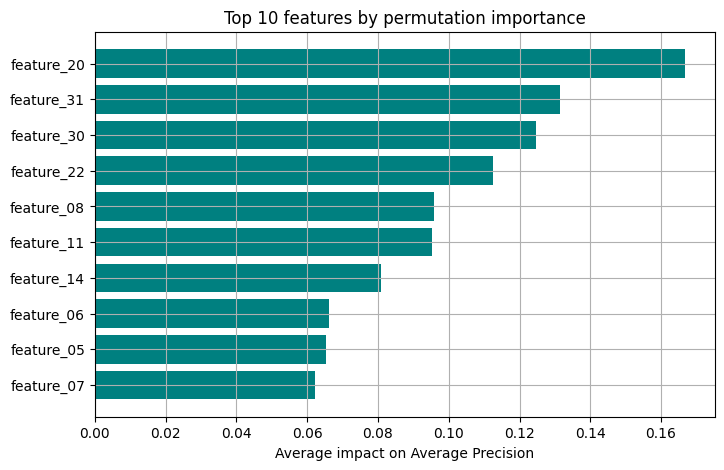

In [20]:

plt.figure(figsize=(8, 5))
plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1], color='teal')
plt.title('Top 10 features by permutation importance')
plt.xlabel('Average impact on Average Precision')
plt.show()



# 9. Case 2 — Anomaly Detection with an Autoencoder

## Business problem
Supervised fraud detection is powerful when labels are available and reliable. In practice, however:
- some fraud labels arrive late,
- some fraud patterns evolve over time,
- and some suspicious behaviors may never have been seen before.

## Why use an autoencoder?
An **autoencoder** learns the structure of normal transactions. If a transaction is reconstructed poorly, that suggests that the pattern is atypical.

## Why this complements the supervised model
The two approaches answer slightly different questions:
- **MLP**: “does this look like known fraud?”
- **Autoencoder**: “does this look unlike normal behavior?”

That distinction is useful in real fraud systems, where known fraud patterns and emerging anomalies often coexist.

## Why train only on normal transactions?
The objective is to learn a representation of legitimate behavior. If fraud examples are included heavily in training, reconstruction error may become less informative as an anomaly signal.

## Why this architecture?
- The encoder compresses the input into a lower-dimensional representation.
- The decoder reconstructs the original feature vector.
- A moderate bottleneck forces the model to retain only salient structure.
- Mean squared error is appropriate because the scaled inputs are continuous numerical variables.


In [21]:

X_train_normal = X_train_sc[y_train == 0]
X_val_normal = X_val_sc[y_val == 0]

input_dim = X_train_normal.shape[1]
encoding_dim = 12

inputs = keras.Input(shape=(input_dim,))
x = layers.Dense(24, activation='relu')(inputs)
x = layers.Dense(encoding_dim, activation='relu')(x)
x = layers.Dense(24, activation='relu')(x)
outputs = layers.Dense(input_dim, activation='linear')(x)

autoencoder = keras.Model(inputs, outputs)
autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')

callbacks_ae = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    )
]

history_ae = autoencoder.fit(
    X_train_normal, X_train_normal,
    validation_data=(X_val_normal, X_val_normal),
    epochs=30,
    batch_size=256,
    verbose=0,
    callbacks=callbacks_ae
)

print('Best validation loss (AE):', min(history_ae.history['val_loss']))


Best validation loss (AE): 0.2029670923948288


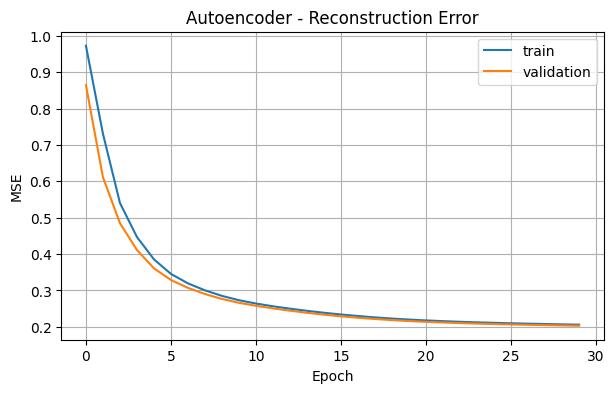

In [22]:

plt.figure(figsize=(7, 4))
plt.plot(history_ae.history['loss'], label='train')
plt.plot(history_ae.history['val_loss'], label='validation')
plt.title('Autoencoder - Reconstruction Error')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()



# 10. Autoencoder Thresholding and Evaluation

## Threshold logic
I define the anomaly threshold using the **99.5th percentile** of the reconstruction error on normal validation transactions.

## Why this makes sense
This approach avoids relying on direct fraud labels to define anomaly behavior. Instead, it flags observations that are unusually hard to reconstruct relative to a normal reference distribution.

This is a practical design when anomaly detection is used as an auxiliary risk signal rather than a fully supervised decision engine.


In [23]:

val_recon = autoencoder.predict(X_val_sc, verbose=0)
val_err = np.mean(np.square(X_val_sc - val_recon), axis=1)

ae_threshold = float(np.percentile(val_err[y_val == 0], 99.5))
print(f'Anomaly threshold: {ae_threshold:.4f}')

X_test_recon = autoencoder.predict(X_test_sc, verbose=0)
ae_test_err = np.mean(np.square(X_test_sc - X_test_recon), axis=1)
ae_test_pred = (ae_test_err >= ae_threshold).astype(int)

ae_roc_auc = roc_auc_score(y_test, ae_test_err)
ae_pr_auc = average_precision_score(y_test, ae_test_err)
ae_precision = precision_score(y_test, ae_test_pred, zero_division=0)
ae_recall = recall_score(y_test, ae_test_pred, zero_division=0)
ae_f1 = f1_score(y_test, ae_test_pred, zero_division=0)

print('=== AUTOENCODER TEST RESULTS ===')
print(f'ROC-AUC  : {ae_roc_auc:.4f}')
print(f'PR-AUC   : {ae_pr_auc:.4f}')
print(f'Precision: {ae_precision:.4f}')
print(f'Recall   : {ae_recall:.4f}')
print(f'F1-score : {ae_f1:.4f}')


Anomaly threshold: 0.5930
=== AUTOENCODER TEST RESULTS ===
ROC-AUC  : 0.7808
PR-AUC   : 0.3289
Precision: 0.5926
Recall   : 0.3265
F1-score : 0.4211


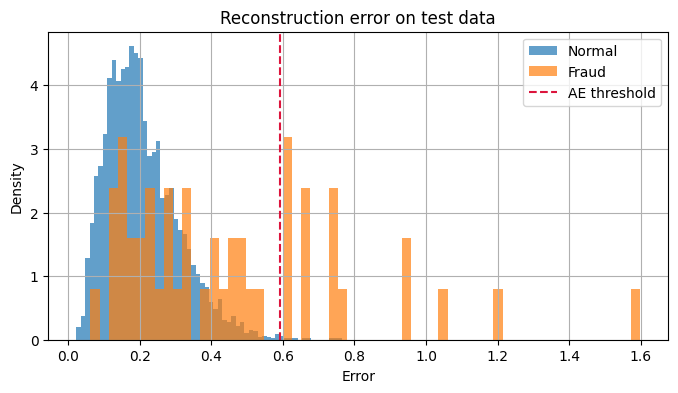

In [24]:

plt.figure(figsize=(8, 4))
plt.hist(ae_test_err[y_test == 0], bins=60, alpha=0.7, label='Normal', density=True)
plt.hist(ae_test_err[y_test == 1], bins=60, alpha=0.7, label='Fraud', density=True)
plt.axvline(ae_threshold, color='crimson', linestyle='--', label='AE threshold')
plt.title('Reconstruction error on test data')
plt.xlabel('Error')
plt.ylabel('Density')
plt.legend()
plt.show()


In [25]:

comparison_fraud = pd.DataFrame([
    ['MLP supervised', mlp_roc_auc, mlp_pr_auc, mlp_precision, mlp_recall, mlp_f1],
    ['Autoencoder', ae_roc_auc, ae_pr_auc, ae_precision, ae_recall, ae_f1]
], columns=['Model', 'ROC_AUC', 'PR_AUC', 'Precision', 'Recall', 'F1']).round(4)

comparison_fraud


,Model,ROC_AUC,PR_AUC,Precision,Recall,F1
0,MLP supervised,0.7572,0.5941,0.9000,0.5510,0.6835
1,Autoencoder,0.7808,0.3289,0.5926,0.3265,0.4211



## Professional interpretation of the fraud results
In most cases, a supervised model should outperform an autoencoder when high-quality labels are available. Even so, the autoencoder remains valuable because it can:
- detect unusual patterns that differ from normal behavior,
- contribute to alert prioritization,
- and act as a complementary score in a hybrid fraud decision engine.

From a product perspective, this is closer to how robust risk systems are often built: supervised scores, anomaly scores, and business rules are combined rather than treated as mutually exclusive.



# 11. Case 3 — GRU for Financial Time-Series Regime Prediction

## Business problem
The focus now moves from individual transactions to sequential market behavior. This resembles problems such as:
- early detection of volatility spikes,
- market risk alerts,
- liquidity stress monitoring,
- or sequence-based forecasting of regime changes.

## Why use a GRU?
A **Gated Recurrent Unit (GRU)** is designed to capture temporal dependencies. Unlike tabular models that treat rows independently, a GRU can process ordered windows of past observations.

## Why not use a classical tabular classifier here?
Because order matters. A single row of market features loses the context of what happened just before it.

## Why GRU instead of LSTM?
GRUs are often a strong practical compromise:
- they capture sequential memory,
- they are lighter than LSTMs,
- and they remain easy to justify in a portfolio notebook.

## Data generation logic
I simulate a synthetic financial time series with two latent regimes:
- **low volatility**,
- **high volatility**.

This makes the sequence problem interpretable and close to real financial intuition.


In [26]:

np.random.seed(SEED)
T = 2200

regime = np.zeros(T, dtype=int)
for t in range(1, T):
    if regime[t - 1] == 0:
        regime[t] = 1 if np.random.rand() < 0.03 else 0
    else:
        regime[t] = 0 if np.random.rand() < 0.12 else 1

vol = np.where(regime == 0, 0.008, 0.03)
trend = np.where(regime == 0, 0.0003, -0.0002)
noise = np.random.normal(size=T)
returns = trend + vol * noise

volume = 100 + 500 * np.abs(returns) + np.random.normal(0, 5, size=T)
spread = 0.5 + 8 * vol + np.random.normal(0, 0.02, size=T)
sentiment_proxy = np.tanh(np.convolve(returns, np.ones(5) / 5, mode='same') * 40)

series_df = pd.DataFrame({
    'return': returns,
    'volume': volume,
    'spread': spread,
    'sentiment_proxy': sentiment_proxy,
    'high_vol_regime': regime
})

series_df['ret_1'] = series_df['return'].shift(1)
series_df['ret_2'] = series_df['return'].shift(2)
series_df['ret_3'] = series_df['return'].shift(3)
series_df['vol_5'] = series_df['return'].rolling(5).std()
series_df['vol_20'] = series_df['return'].rolling(20).std()
series_df['ma_5'] = series_df['return'].rolling(5).mean()
series_df['ma_20'] = series_df['return'].rolling(20).mean()
series_df['vol_chg'] = series_df['volume'].pct_change()
series_df['spread_chg'] = series_df['spread'].pct_change()

series_df['target_next_high_vol'] = series_df['high_vol_regime'].shift(-1)
series_df = series_df.dropna().reset_index(drop=True)

series_df.head()


,return,volume,spread,sentiment_proxy,high_vol_regime,ret_1,ret_2,ret_3,vol_5,vol_20,ma_5,ma_20,vol_chg,spread_chg,target_next_high_vol
0,-0.009088,108.945437,0.727685,-0.609433,1,-0.056756,0.002556,-0.027521,0.022439,0.016295,-0.022076,-0.004875,-0.164725,-0.003471,1.0
1,-0.048391,127.138918,0.725652,-0.444673,1,-0.009088,-0.056756,0.002556,0.025170,0.018860,-0.027840,-0.007411,0.166996,-0.002794,1.0
2,0.023177,111.168874,0.733108,-0.228817,1,-0.048391,-0.009088,-0.056756,0.033995,0.020019,-0.017700,-0.006242,-0.125611,0.010275,1.0
3,0.031303,117.317859,0.746321,-0.058972,1,0.023177,-0.048391,-0.009088,0.040151,0.021699,-0.011951,-0.004616,0.055312,0.018023,1.0
4,-0.026119,113.908492,0.728680,0.494713,1,0.031303,0.023177,-0.048391,0.033369,0.022224,-0.005824,-0.005560,-0.029061,-0.023638,1.0



## Why these time-series variables were chosen
The features are synthetic but intentionally designed to resemble common market microstructure or risk-monitoring signals:
- **return**: the core price movement signal.
- **volume**: trading intensity often increases during stress or significant price moves.
- **spread**: market friction and uncertainty proxy.
- **sentiment_proxy**: a smoothed directional signal that acts like a market tone indicator.
- **lagged returns (`ret_1`, `ret_2`, `ret_3`)**: short-term memory of recent moves.
- **rolling volatility (`vol_5`, `vol_20`)**: local risk level at different horizons.
- **moving averages (`ma_5`, `ma_20`)**: short-term trend context.
- **volume and spread changes**: accelerations that may precede regime shifts.

## Why predict the next step regime?
The target is whether the **next observation** belongs to a high-volatility regime. This creates a forecasting-style classification problem rather than a descriptive one.


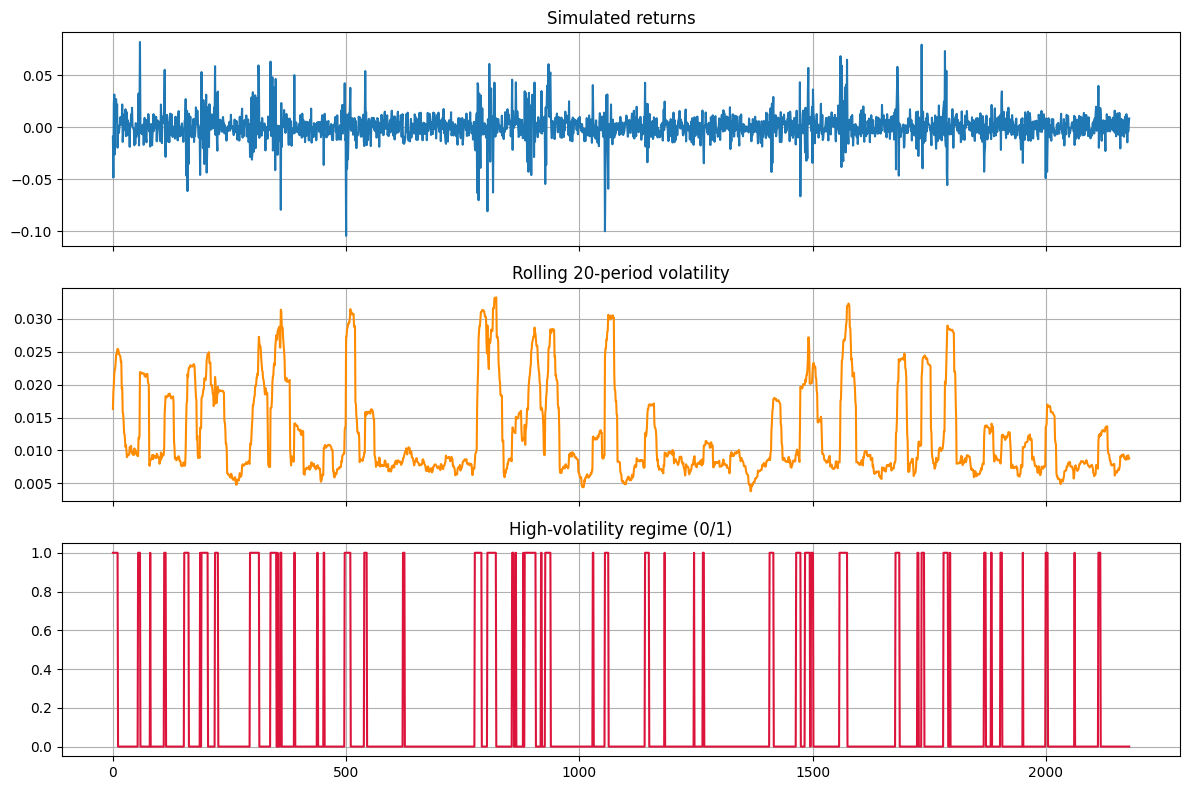

In [27]:

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(series_df['return'].values)
axes[0].set_title('Simulated returns')
axes[1].plot(series_df['vol_20'].values, color='darkorange')
axes[1].set_title('Rolling 20-period volatility')
axes[2].plot(series_df['high_vol_regime'].values, color='crimson')
axes[2].set_title('High-volatility regime (0/1)')
plt.tight_layout()
plt.show()



# 12. Sequential Data Preparation

A GRU does not operate on single rows. It needs a **window of consecutive observations**.

In this notebook, I use sequences of length **20**, which means the model sees the previous 20 time steps in order to predict whether the next step will be a high-volatility regime.

## Why this matters
This conversion is essential because recurrent networks expect 3D tensors with shape:
- `(number_of_samples, sequence_length, number_of_features)`

## Why use a temporal split instead of random shuffling?
Because time-series modeling should respect chronology. Random shuffling would leak future information into the past and artificially improve results.


In [28]:

seq_features = [
    'return', 'volume', 'spread', 'sentiment_proxy',
    'ret_1', 'ret_2', 'ret_3', 'vol_5', 'vol_20',
    'ma_5', 'ma_20', 'vol_chg', 'spread_chg'
]
target_col = 'target_next_high_vol'
sequence_length = 20

train_end = int(len(series_df) * 0.70)
val_end = int(len(series_df) * 0.85)

train_df = series_df.iloc[:train_end].copy()
val_df = series_df.iloc[train_end:val_end].copy()
test_df = series_df.iloc[val_end:].copy()

scaler_ts = StandardScaler()
train_df[seq_features] = scaler_ts.fit_transform(train_df[seq_features])
val_df[seq_features] = scaler_ts.transform(val_df[seq_features])
test_df[seq_features] = scaler_ts.transform(test_df[seq_features])

def build_sequences(df_, feature_cols, target, seq_len=20):
    Xs, ys = [], []
    vals = df_[feature_cols + [target]].values
    for i in range(seq_len, len(df_)):
        Xs.append(vals[i-seq_len:i, :len(feature_cols)])
        ys.append(vals[i, len(feature_cols)])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_train_ts, y_train_ts = build_sequences(train_df, seq_features, target_col, sequence_length)
X_val_ts, y_val_ts = build_sequences(val_df, seq_features, target_col, sequence_length)
X_test_ts, y_test_ts = build_sequences(test_df, seq_features, target_col, sequence_length)

print('Train:', X_train_ts.shape, y_train_ts.shape)
print('Val  :', X_val_ts.shape, y_val_ts.shape)
print('Test :', X_test_ts.shape, y_test_ts.shape)
print('Positive rate in train:', float(y_train_ts.mean()))


Train: (1506, 20, 13) (1506,)
Val  : (307, 20, 13) (307,)
Test : (307, 20, 13) (307,)
Positive rate in train: 0.16268260776996613



# 13. GRU Model

## Why this architecture?
- **GRU(32)** captures temporal patterns with moderate complexity.
- **Dropout** helps control overfitting.
- **Dense hidden layer** adds decision flexibility after the recurrent representation.
- **Sigmoid output** returns the probability of entering a high-volatility regime in the next step.

## Why use class weights again?
If the high-volatility regime is less frequent, class weights help the model treat missed positive events more seriously during training.


In [29]:

num_features = X_train_ts.shape[2]

gru_model = keras.Sequential([
    layers.Input(shape=(sequence_length, num_features)),
    layers.GRU(32, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

gru_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc')]
)

neg_ts = (y_train_ts == 0).sum()
pos_ts = (y_train_ts == 1).sum()
class_weight_ts = {0: 1.0, 1: float(neg_ts / pos_ts) * 0.7}

history_gru = gru_model.fit(
    X_train_ts, y_train_ts,
    validation_data=(X_val_ts, y_val_ts),
    epochs=25,
    batch_size=64,
    verbose=0,
    class_weight=class_weight_ts,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True)]
)

print('Best validation AUC (GRU):', max(history_gru.history['val_auc']))


Best validation AUC (GRU): 0.9249125719070435


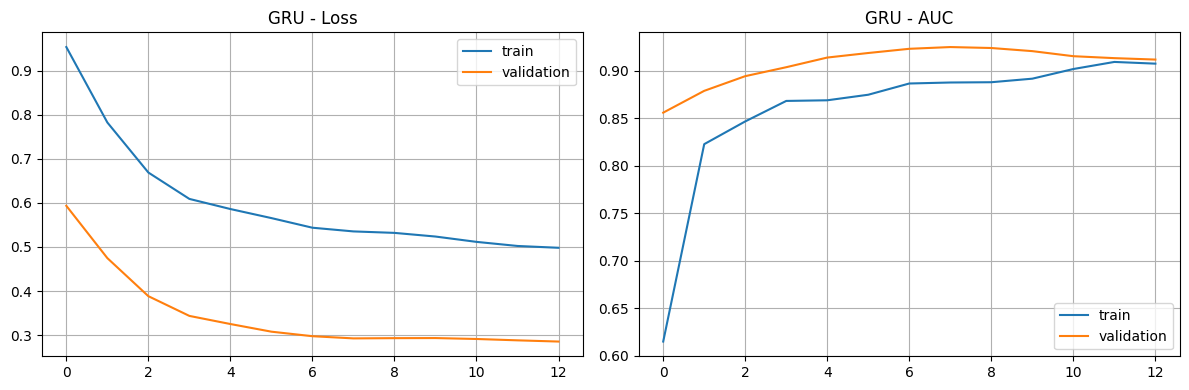

In [30]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_gru.history['loss'], label='train')
axes[0].plot(history_gru.history['val_loss'], label='validation')
axes[0].set_title('GRU - Loss')
axes[0].legend()

axes[1].plot(history_gru.history['auc'], label='train')
axes[1].plot(history_gru.history['val_auc'], label='validation')
axes[1].set_title('GRU - AUC')
axes[1].legend()

plt.tight_layout()
plt.show()



# 14. Threshold Selection and GRU Evaluation

As in the fraud case, I select the classification threshold on the validation set by maximizing F1 score. This is a practical way to transform a probability model into an operational alerting rule.


In [32]:

val_scores_ts = gru_model.predict(X_val_ts, verbose=0).ravel()
ths_ts = np.linspace(0.1, 0.9, 81)
f1s_ts = [f1_score(y_val_ts, (val_scores_ts >= t).astype(int), zero_division=0) for t in ths_ts]

best_thr_ts = float(ths_ts[int(np.argmax(f1s_ts))])
print('Best GRU threshold:', best_thr_ts)

test_scores_ts = gru_model.predict(X_test_ts, verbose=0).ravel()
test_pred_ts = (test_scores_ts >= best_thr_ts).astype(int)

gru_roc_auc = roc_auc_score(y_test_ts, test_scores_ts)
gru_pr_auc = average_precision_score(y_test_ts, test_scores_ts)
gru_precision = precision_score(y_test_ts, test_pred_ts, zero_division=0)
gru_recall = recall_score(y_test_ts, test_pred_ts, zero_division=0)
gru_f1 = f1_score(y_test_ts, test_pred_ts, zero_division=0)

print('=== GRU TEST RESULTS ===')
print(f'ROC-AUC  : {gru_roc_auc:.4f}')
print(f'PR-AUC   : {gru_pr_auc:.4f}')
print(f'Precision: {gru_precision:.4f}')
print(f'Recall   : {gru_recall:.4f}')
print(f'F1-score : {gru_f1:.4f}')
print('Classification report:')
print(classification_report(y_test_ts, test_pred_ts, digits=4))


Best GRU threshold: 0.65
=== GRU TEST RESULTS ===
ROC-AUC  : 0.6284
PR-AUC   : 0.2062
Precision: 0.3500
Recall   : 0.3889
F1-score : 0.3684
Classification report:
              precision    recall  f1-score   support

         0.0     0.9617    0.9550    0.9583       289
         1.0     0.3500    0.3889    0.3684        18

    accuracy                         0.9218       307
   macro avg     0.6558    0.6720    0.6634       307
weighted avg     0.9258    0.9218    0.9237       307



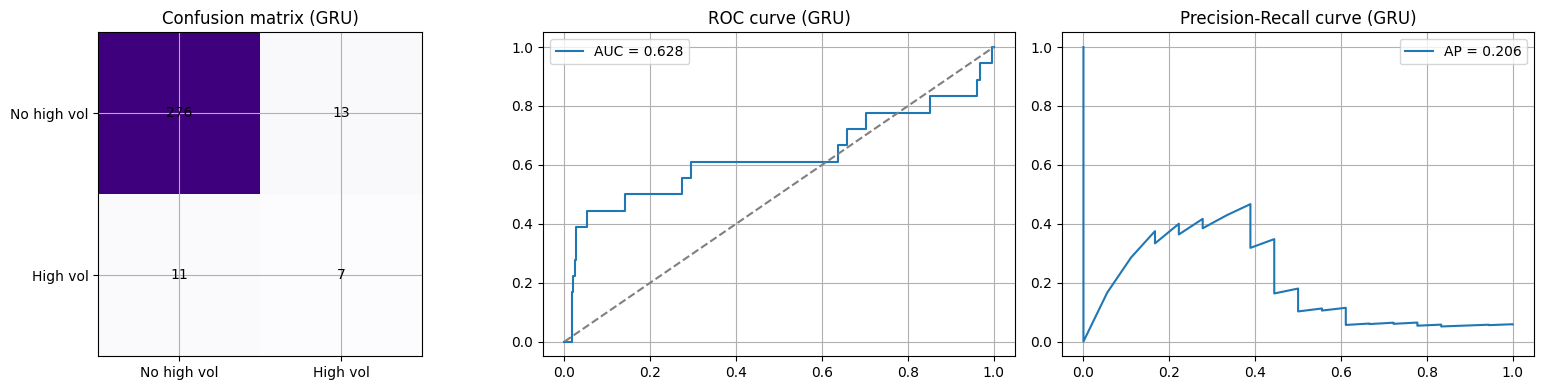

In [33]:

cm_ts = confusion_matrix(y_test_ts, test_pred_ts)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].imshow(cm_ts, cmap='Purples')
axes[0].set_title('Confusion matrix (GRU)')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['No high vol', 'High vol'])
axes[0].set_yticklabels(['No high vol', 'High vol'])
for (i, j), v in np.ndenumerate(cm_ts):
    axes[0].text(j, i, str(v), ha='center', va='center')

fpr_ts, tpr_ts, _ = roc_curve(y_test_ts, test_scores_ts)
axes[1].plot(fpr_ts, tpr_ts, label=f'AUC = {gru_roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_title('ROC curve (GRU)')
axes[1].legend()

p_ts, r_ts, _ = precision_recall_curve(y_test_ts, test_scores_ts)
axes[2].plot(r_ts, p_ts, label=f'AP = {gru_pr_auc:.3f}')
axes[2].set_title('Precision-Recall curve (GRU)')
axes[2].legend()

plt.tight_layout()
plt.show()



# 15. Executive Summary of Results

The goal of this section is to consolidate all three modeling exercises into one table so that performance can be compared and the project can be defended more clearly.


In [34]:

summary = pd.DataFrame([
    ['Fraud - Supervised MLP', mlp_roc_auc, mlp_pr_auc, mlp_precision, mlp_recall, mlp_f1],
    ['Fraud - Autoencoder', ae_roc_auc, ae_pr_auc, ae_precision, ae_recall, ae_f1],
    ['Time series - GRU', gru_roc_auc, gru_pr_auc, gru_precision, gru_recall, gru_f1],
], columns=['Case', 'ROC_AUC', 'PR_AUC', 'Precision', 'Recall', 'F1']).round(4)

summary


,Case,ROC_AUC,PR_AUC,Precision,Recall,F1
0,Fraud - Supervised MLP,0.7572,0.5941,0.9000,0.5510,0.6835
1,Fraud - Autoencoder,0.7808,0.3289,0.5926,0.3265,0.4211
2,Time series - GRU,0.6284,0.2062,0.3500,0.3889,0.3684



# 16. How I Would Defend Each Modeling Choice

## MLP for fraud detection
I selected an MLP because fraud on tabular data often depends on non-linear interactions across multiple behavioral and transactional variables. It is a clear and defensible deep learning baseline for rare-event classification.

## Autoencoder for anomaly detection
I included an autoencoder because fraud patterns evolve and labeled fraud data is not always complete. Reconstruction-based anomaly scoring is useful as a complementary layer for unusual behavior detection.

## GRU for time-series risk signals
I used a GRU because volatility and market stress are sequential phenomena. A recurrent model can use temporal context in ways a static classifier cannot.



# 17. Practical Limitations and Next Improvements

## Honest limitations of this version
- The datasets are synthetic.
- Hyperparameter tuning is intentionally limited.
- The time-series validation is not a full walk-forward framework.
- There is no deployment layer or scoring API yet.

## Natural next steps for a stronger production-oriented version
1. Replace the synthetic fraud dataset with a real public benchmark.
2. Compare against XGBoost and LightGBM.
3. Add SHAP or a stronger interpretability workflow.
4. Expose the scoring logic through a FastAPI service.
5. Build a monitoring dashboard for drift, alert quality, and threshold management.

These limitations do not weaken the project. On the contrary, acknowledging them shows technical judgment and a realistic view of what separates a strong prototype from a production system.



# 18. Portfolio Positioning

This project is designed to show more than model training. It demonstrates that I can:
- frame ML problems in business terms,
- select architectures that match the data structure,
- handle imbalanced classification correctly,
- work with both supervised and unsupervised approaches,
- and document results in a way that is understandable for stakeholders in financial services.

That combination is highly relevant for AI engineering roles in banking, fraud, risk, and advanced analytics.
